# Topic Modelling

In [17]:
!pip install pandas numpy gensim bertopic scikit-learn matplotlib
!pip install sentence-transformers umap-learn hdbscan

import pandas as pd
import numpy as np
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from bertopic import BERTopic
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [18]:
INPUT_FILE = "kfc_negative_comments.csv"

df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} negative comments")

documents = df["Tokenised_Comment"].tolist()
tokenised_docs = [doc.split() for doc in documents]

Loaded 4035 negative comments


##LDA

In [19]:
#BoW corpus
dictionary = corpora.Dictionary(tokenised_docs)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in tokenised_docs]
print(f"Dictionary: {len(dictionary)} tokens | Corpus: {len(corpus)} docs")

Dictionary: 1771 tokens | Corpus: 4035 docs


In [20]:
#optimal topics
topic_range = range(2, 11)
coherence_scores = []

for n in topic_range:
    model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=n,
                     random_state=42, passes=15, alpha="auto", eta="auto")
    cm = CoherenceModel(model=model, texts=tokenised_docs,
                        dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"  Topics={n:2d}  Coherence={score:.4f}")

best_idx = np.argmax(coherence_scores)
best_n = list(topic_range)[best_idx]
best_coh = coherence_scores[best_idx]
print(f"\nBest: {best_n} topics (coherence = {best_coh:.4f})")

  Topics= 2  Coherence=0.5982
  Topics= 3  Coherence=0.5005
  Topics= 4  Coherence=0.4553
  Topics= 5  Coherence=0.4306
  Topics= 6  Coherence=0.3727
  Topics= 7  Coherence=0.4127
  Topics= 8  Coherence=0.3888
  Topics= 9  Coherence=0.3855
  Topics=10  Coherence=0.3797

Best: 2 topics (coherence = 0.5982)


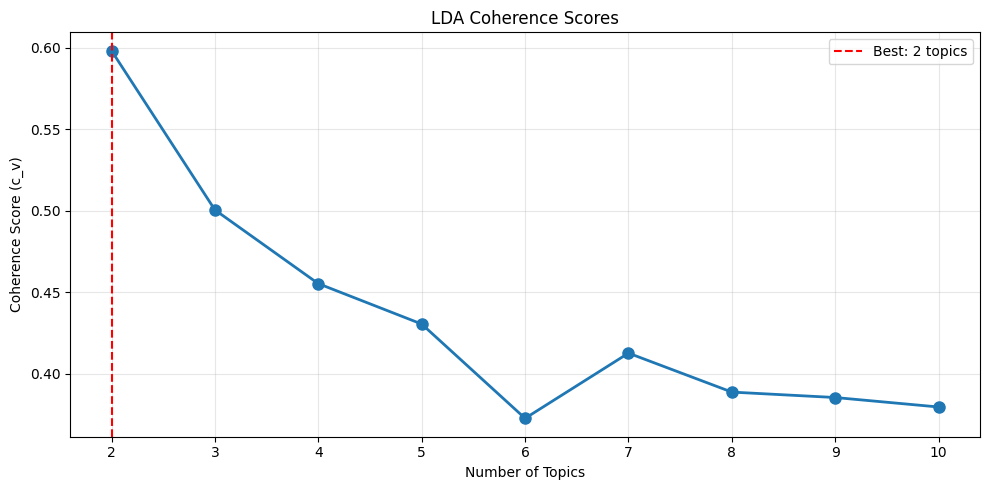

In [5]:
#coherence plot
plt.figure(figsize=(10, 5))
plt.plot(list(topic_range), coherence_scores, "o-", linewidth=2, markersize=8)
plt.axvline(x=best_n, color="red", linestyle="--", label=f"Best: {best_n} topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("LDA Coherence Scores")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lda_coherence_plot.png", dpi=150)
plt.show()

In [6]:
#LDA model
final_lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=best_n,
                     random_state=42, passes=20, alpha="auto", eta="auto")

lda_data = []
for i in range(best_n):
    kw = [w for w, _ in final_lda.show_topic(i, topn=10)]
    print(f"  Topic {i}: {', '.join(kw)}")
    lda_data.append({"Topic": i, "Top Keywords": ", ".join(kw)})

pd.DataFrame(lda_data).to_csv("lda_topics.csv", index=False)

all_w = [w for i in range(best_n) for w, _ in final_lda.show_topic(i, topn=10)]
lda_div = len(set(all_w)) / len(all_w)
print(f"\nLDA Diversity: {lda_div:.3f}")

  Topic 0: price, v, per, doordash, unit, cost, volume, item, double, sell
  Topic 1: chicken, year, fryer, fry, oil, cook, never, piece, local, taste

LDA Diversity: 1.000


## BERTopic

In [27]:
#Training
raw_docs = df["Tokenised_Comment"].tolist()

topic_model = BERTopic(
    language="english",
    min_topic_size=10,
    nr_topics="auto",
    verbose=True,
)

topics, probs = topic_model.fit_transform(raw_docs)

2026-04-10 17:15:42,080 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/127 [00:00<?, ?it/s]

2026-04-10 17:16:23,266 - BERTopic - Embedding - Completed ✓
2026-04-10 17:16:23,268 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-10 17:16:54,298 - BERTopic - Dimensionality - Completed ✓
2026-04-10 17:16:54,299 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-10 17:16:54,472 - BERTopic - Cluster - Completed ✓
2026-04-10 17:16:54,473 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-10 17:16:54,602 - BERTopic - Representation - Completed ✓
2026-04-10 17:16:54,603 - BERTopic - Topic reduction - Reducing number of topics
2026-04-10 17:16:54,630 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-10 17:16:54,724 - BERTopic - Representation - Completed ✓
2026-04-10 17:16:54,730 - BERTopic - Topic reduction - Reduced number of topics from 81 to 26


In [28]:
#extract results
topic_info = topic_model.get_topic_info()
n_topics = len(topic_info) - 1

bert_data = []
for _, row in topic_info[topic_info["Topic"] != -1].iterrows():
    tid = row["Topic"]
    kw = [w for w, _ in topic_model.get_topic(tid)[:10]]
    print(f"  Topic {tid}: {', '.join(kw)}")
    bert_data.append({"Topic": tid, "Count": row["Count"],
                      "Top Keywords": ", ".join(kw), "Interpreted Theme": ""})

pd.DataFrame(bert_data).to_csv("bertopic_themes.csv", index=False)

  Topic 0: chicken, cook, price, fry, manager, expensive, oil, job, popeyes, never
  Topic 1: gross, joke, nasty, worse, terrible, suck, look, happened, dumb, whats
  Topic 2: trash, bin, recycling, receptacle, garbage, waste, dump, end, sorting, overflowing
  Topic 3: tip, tipping, driver, company, optional, culture, worker, expectation, doesnt, fee
  Topic 4: bucket, free, piece, app, distance, building, shown, theyve, group, werent
  Topic 5: year, havent, early, since, decline, grader, retired, retire, ghosting, grim
  Topic 6: wrong, opinion, mixed, ight, respectfully, politically, spelled, liking, nothing, right
  Topic 7: american, america, country, immigration, pakistan, racist, ist, gypsy, uk, foreign
  Topic 8: never, ever, sometime, myth, recommend, tonight, shut, dude, usually, day
  Topic 9: app, computer, exploitive, advertises, galaxy, install, apple, dogshit, ultra, cctv
  Topic 10: bite, teeth, grab, mouth, took, biting, bitz, fizzled, ehhh, salivating
  Topic 11: wtf,

In [29]:
#coherence and diversity
all_bw, tw_lists = [], []
for _, row in topic_info[topic_info["Topic"] != -1].iterrows():
    kw = [w for w, _ in topic_model.get_topic(row["Topic"])[:10]]
    all_bw.extend(kw); tw_lists.append(kw)

bert_div = len(set(all_bw)) / len(all_bw) if all_bw else 0

try:
    bcm = CoherenceModel(topics=tw_lists, texts=tokenised_docs,
                         dictionary=dictionary, coherence="c_v")
    bert_coh = bcm.get_coherence()
    print(f"BERTopic Coherence: {bert_coh:.4f}")
except Exception as e:
    bert_coh = None
    print(f"Could not compute coherence: {e}")

print(f"BERTopic Diversity: {bert_div:.3f}")

BERTopic Coherence: 0.4984
BERTopic Diversity: 0.944


In [30]:
comparison = pd.DataFrame({
    "Metric": ["Coherence Score", "Topic Diversity", "Number of Topics"],
    "LDA": [f"{best_coh:.3f}", f"{lda_div:.3f}", str(best_n)],
    "BERTopic": [f"{bert_coh:.3f}" if bert_coh else "N/A", f"{bert_div:.3f}", str(n_topics)],
})
print(comparison.to_string(index=False))
comparison.to_csv("topic_comparison.csv", index=False)

          Metric   LDA BERTopic
 Coherence Score 0.598    0.498
 Topic Diversity 1.000    0.944
Number of Topics     2       25
